# 🏥 MedShare: Maternal Health — MI Privacy Audit

**Membership Inference Audit: σ ∈ {0, 0.05, 0.1, 0.2, 0.5}**

---


In [1]:
## 🛸 PHASE 1: SYSTEM INITIALIZATION (Setup & Infrastructure)
from google.colab import drive
import os, torch, multiprocessing, psutil, socket, time, subprocess, json, urllib.request, shutil

# 1.1 Drive Sync
print("1.1 Mounting Google Drive...")
os.chdir('/content')
drive.mount('/content/drive', force_remount=True)

POSSIBLE_PATHS = [
    '/content/drive/Othercomputers/My laptop/bxp267',
    '/content/drive/MyDrive/bxp267',
    '/content/drive/MyDrive/coding/bxp267'
]
PROJECT_PATH = next((p for p in POSSIBLE_PATHS if os.path.exists(p)), None)
if not PROJECT_PATH:
    raise Exception("❌ Project folder not found. Please mount Drive and check path.")
%cd "$PROJECT_PATH"

# 1.2 Hardware Pre-flight
print("\n1.2 Calibrating Hardware...")
if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)} ({torch.cuda.get_device_properties(0).total_memory/1e9:.1f}GB VRAM)")
    print("[Hardware] Mode: Colab MAX Performance Enabled")
else: print("⚠️ GPU NOT FOUND. Using CPU fallback.")

# 1.3 Dependency Installation
print("\n1.3 Installing Core Engines...")
!pip install -q "protobuf<6" "cryptography<44" "flwr[simulation]" opacus ucimlrepo web3 kagglehub imbalanced-learn
!npm install -g ganache --legacy-peer-deps 2>&1 | tail -1

# 1.4 Blockchain Initialization
# Kill any old ganache process on 8545, start fresh, compile + deploy all contracts
print("\n1.4 Provisioning Blockchain...")
!lsof -ti:8545 | xargs kill -9 > /dev/null 2>&1
ganache_proc = subprocess.Popen(
    ["ganache", "--port", "8545", "--miner.blockGasLimit", "0xffffffffffff"],
    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
)
time.sleep(6)  # Allow ganache to fully boot

# Compile Solidity contracts (MedShareTask, CommitmentRegistry, Reputation)
print("Compiling smart contracts...")
result = subprocess.run(["npx", "hardhat", "compile"], capture_output=True, text=True)
if result.returncode != 0:
    print("⚠️ Compile warning:", result.stderr[-500:])
else:
    print("✅ Contracts compiled successfully")

# Copy compiled ABIs to build/ for deploy script
os.makedirs("build", exist_ok=True)
for c in ["MedShareTask", "CommitmentRegistry", "Reputation"]:
    shutil.copy(f"artifacts/contracts/{c}.sol/{c}.json", f"build/{c}.json")

# Deploy contracts to local ganache chain
print("Deploying contracts to local chain...")
deploy_result = subprocess.run(["python", "scripts/deploy_colab.py"], capture_output=True, text=True)
print(deploy_result.stdout[-1000:])
if deploy_result.returncode != 0:
    print("⚠️ Deploy stderr:", deploy_result.stderr[-500:])
else:
    print("✅ Contracts deployed successfully")

print("\n" + "="*70)
print("🏁 INITIALIZATION SUCCESS: Blockchain is LIVE, Contracts are DEPLOYED")
print("="*70)


1.1 Mounting Google Drive...
Mounted at /content/drive
/content/drive/Othercomputers/My laptop/bxp267

1.2 Calibrating Hardware...
✅ GPU: Tesla T4 (15.6GB VRAM)
[Hardware] Mode: Colab MAX Performance Enabled

1.3 Installing Core Engines...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.7/66.7 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.4/254.4 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 587.5/587.5 kB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.4/51.4 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.7/251.7 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4

In [2]:
## 🛸 PHASE 2: MEMBERSHIP INFERENCE AUDIT — Maternal Health
# Explicit loop over sigmas so we can save specific dashboard JSONs after each run
import subprocess, os, shutil

mi_csv = 'test/exp_mi_results.csv'
if os.path.exists(mi_csv): os.remove(mi_csv)

for f in os.listdir('test'):
    if f.startswith('centralized_Maternal') or f.startswith('baseline_Maternal'):
        os.remove(os.path.join('test', f))

sigmas = [0, 0.05, 0.1, 0.2, 0.5]
print(f'\n🚀 STARTING EXPLICIT MI AUDIT: {sigmas}')
print('='*70)

for s in sigmas:
    print(f'\n[Sweep] Running sigma={s}...')
    result = subprocess.run([
        'python', 'federated_survival.py',
        '--experiment', 'mi_step',
        '--dataset', 'maternal_health',
        '--enable_blockchain', 'True',
        '--sigma', str(s)
    ])

    if result.returncode != 0:
        print(f'⚠️ Error on sigma={s}')
        break

    # Save frontend copies specifically for this sigma!
    data_dir = os.path.join('frontend', 'src', 'data')
    os.makedirs(data_dir, exist_ok=True)
    for file_name in ['comparison_stats.json', 'training_history.json']:
        src = os.path.join(data_dir, file_name)
        dst = os.path.join(data_dir, f'{file_name.split(".")[0]}_sigma_{s}.json')
        if os.path.exists(src):
            shutil.copy(src, dst)
            print(f'   💾 Saved copy: {dst}')

print('\n' + '='*70)
print('✅ MI AUDIT COMPLETE — View individual sigma JSONs in frontend/src/data/')
print('='*70)



🚀 STARTING EXPLICIT MI AUDIT: [0, 0.05, 0.1, 0.2, 0.5]

[Sweep] Running sigma=0...
   💾 Saved copy: frontend/src/data/comparison_stats_sigma_0.json
   💾 Saved copy: frontend/src/data/training_history_sigma_0.json

[Sweep] Running sigma=0.05...
   💾 Saved copy: frontend/src/data/comparison_stats_sigma_0.05.json
   💾 Saved copy: frontend/src/data/training_history_sigma_0.05.json

[Sweep] Running sigma=0.1...
   💾 Saved copy: frontend/src/data/comparison_stats_sigma_0.1.json
   💾 Saved copy: frontend/src/data/training_history_sigma_0.1.json

[Sweep] Running sigma=0.2...
   💾 Saved copy: frontend/src/data/comparison_stats_sigma_0.2.json
   💾 Saved copy: frontend/src/data/training_history_sigma_0.2.json

[Sweep] Running sigma=0.5...
   💾 Saved copy: frontend/src/data/comparison_stats_sigma_0.5.json
   💾 Saved copy: frontend/src/data/training_history_sigma_0.5.json

✅ MI AUDIT COMPLETE — View individual sigma JSONs in frontend/src/data/


Generating plots...
Working directory set to: /content/drive/Othercomputers/My laptop/bxp267/test
--- Attempting to plot fig_dp_tradeoff.png ---
DEBUG: Checking for DP results at: /content/drive/Othercomputers/My laptop/bxp267/test/exp_dp_results.csv
[OK] Generated /content/drive/Othercomputers/My laptop/bxp267/test/fig_dp_tradeoff.png
--- Attempting to plot fig_robustness.png ---
DEBUG: Entered plot_robustness
DEBUG: Loaded 6 rows from /content/drive/Othercomputers/My laptop/bxp267/test/exp_robustness_results.csv
[OK] Generated /content/drive/Othercomputers/My laptop/bxp267/test/fig_robustness.png
--- Attempting to plot fig_gas_costs.png ---
Error loading gas logs: Error tokenizing data. C error: Expected 3 fields in line 3823, saw 4

[FAIL] Skipped fig_gas_costs.png (func returned False)
--- Attempting to plot fig_latency.png ---
DEBUG: Loaded 20 rows from exp_latency_log.csv
[OK] Generated /content/drive/Othercomputers/My laptop/bxp267/test/fig_latency.png
--- Attempting to plot fig

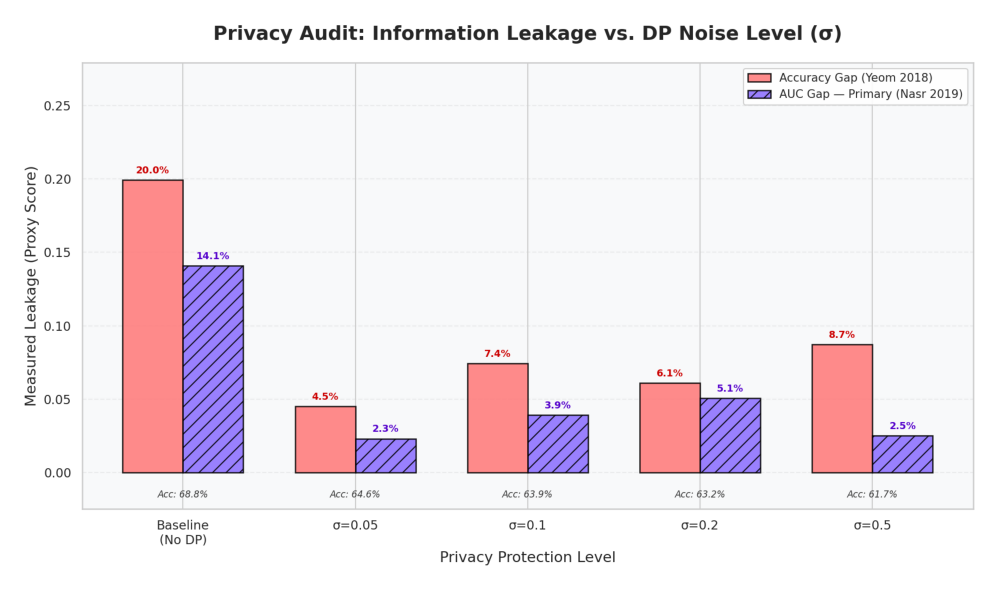


✅ Figure saved to docs/assets/maternal_health-mi/fig_mi.png

🏆 DONE


In [4]:
## 📈 PHASE 3: PLOT MI RESULTS
import os, pandas as pd, matplotlib.pyplot as plt, matplotlib.image as mpimg

# 3.1 Generate the MI figure (and all other plots)
print("Generating plots...")
!python test/plot_results.py

# 3.2 Verify MI results CSV was written
mi_path = 'test/exp_mi_results.csv'
if os.path.exists(mi_path):
    df = pd.read_csv(mi_path)
    print(f"\n✅ MI results CSV: {len(df)} rows")
    print(df[['mode', 'accuracy', 'leakage_acc', 'leakage_auc']].to_string(index=False))
else:
    print("❌ exp_mi_results.csv NOT FOUND — audit may have failed")

# 3.3 Display the MI figure inline
fig_path = 'test/fig_mi.png'
if os.path.exists(fig_path):
    print("\n🖼️ MI Audit Figure:")
    img = mpimg.imread(fig_path)
    plt.figure(figsize=(13, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("❌ fig_mi.png NOT FOUND")

# 3.4 Also copy to docs/assets for dashboard use
docs_dir = 'docs/assets/maternal_health-mi'
os.makedirs(docs_dir, exist_ok=True)
if os.path.exists(fig_path):
    import shutil
    shutil.copy(fig_path, os.path.join(docs_dir, 'fig_mi.png'))
    print(f"\n✅ Figure saved to {docs_dir}/fig_mi.png")

print("\n" + "="*70)
print("🏆 DONE")
print("="*70)
